In [394]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import community as community_louvain

In [395]:
df = pd.read_csv('input_grafo.csv')
df_downgrades = df[
    df["evento_crediticio"] == "Downgrade"
]

In [396]:
df.head()

,source,periodo_mensual_A,target,evento_crediticio,weight
0,30500120882,2024-05,30509300700,Upgrade,0.301194
1,30500120882,2024-05,30525322749,Upgrade,0.165299
2,30500120882,2024-05,30525698412,Upgrade,0.135335
3,30500120882,2024-05,30526552659,Upgrade,0.301194
4,30500120882,2024-05,30576721710,Upgrade,0.449329


Nodos: 45 | Aristas: 1795


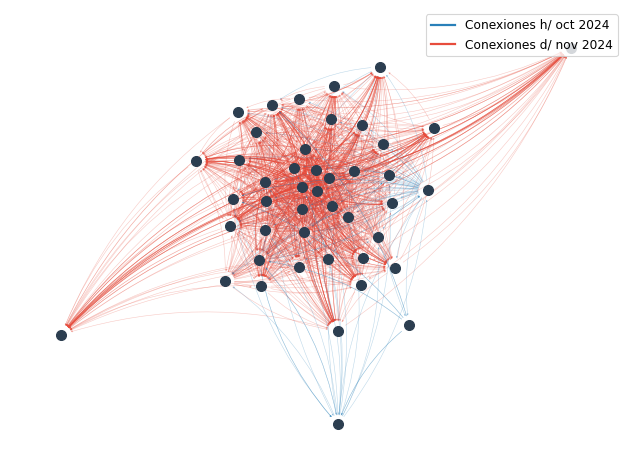

In [397]:
# 1. Crear el MULTIGRAFO DIRIGIDO (Soporta múltiples flechas A -> B)
G_multi = nx.from_pandas_edgelist(
    df_downgrades,
    source="source",
    target="target",
    edge_attr=["weight", "periodo_mensual_A", "evento_crediticio"],
    create_using=nx.MultiDiGraph(),
)

# 2. Clasificar los múltiples enlaces por periodo
edge_colors = []
for u, v, k, data in G_multi.edges(keys=True, data=True):
    fecha = data.get("periodo_mensual_A")

    if int(str(fecha).replace("-", "")[:6]) <= 202410:
        edge_colors.append("#2980b9")  # Época 1: Azul
    else:
        edge_colors.append("#e74c3c")  # Época 2: Rojo

print(f"Nodos: {G_multi.number_of_nodes()} | Aristas: {G_multi.number_of_edges()}")

# =====================================================================
# VISUALIZACIÓN DEL MULTIGRAFO
# =====================================================================
plt.figure(figsize=(8, 6), dpi=80)

pos_multi = nx.spring_layout(G_multi, k=0.7, seed=42)
nx.draw_networkx_nodes(
    G_multi, pos_multi, node_size=80, node_color="#2c3e50", alpha=1
)

nx.draw_networkx_edges(
    G_multi,
    pos_multi,
    edge_color=edge_colors,
    width=0.5,
    alpha=0.3,
    arrowsize=3,
    connectionstyle="arc3,rad=0.15",
)

proxies = [
    plt.Line2D([0], [0], color="#2980b9", lw=2),
    plt.Line2D([0], [0], color="#e74c3c", lw=2),
]
plt.legend(
    proxies,
    ["Conexiones h/ oct 2024", "Conexiones d/ nov 2024"],
    loc="upper right",
    frameon=True,
    fontsize=11,
)
plt.axis("off")
plt.savefig("main_network.png", bbox_inches="tight", dpi=300)
plt.tight_layout()
plt.show()

Nodos totales: 45
Enlaces Azules: 111 | Enlaces Rojos: 1684


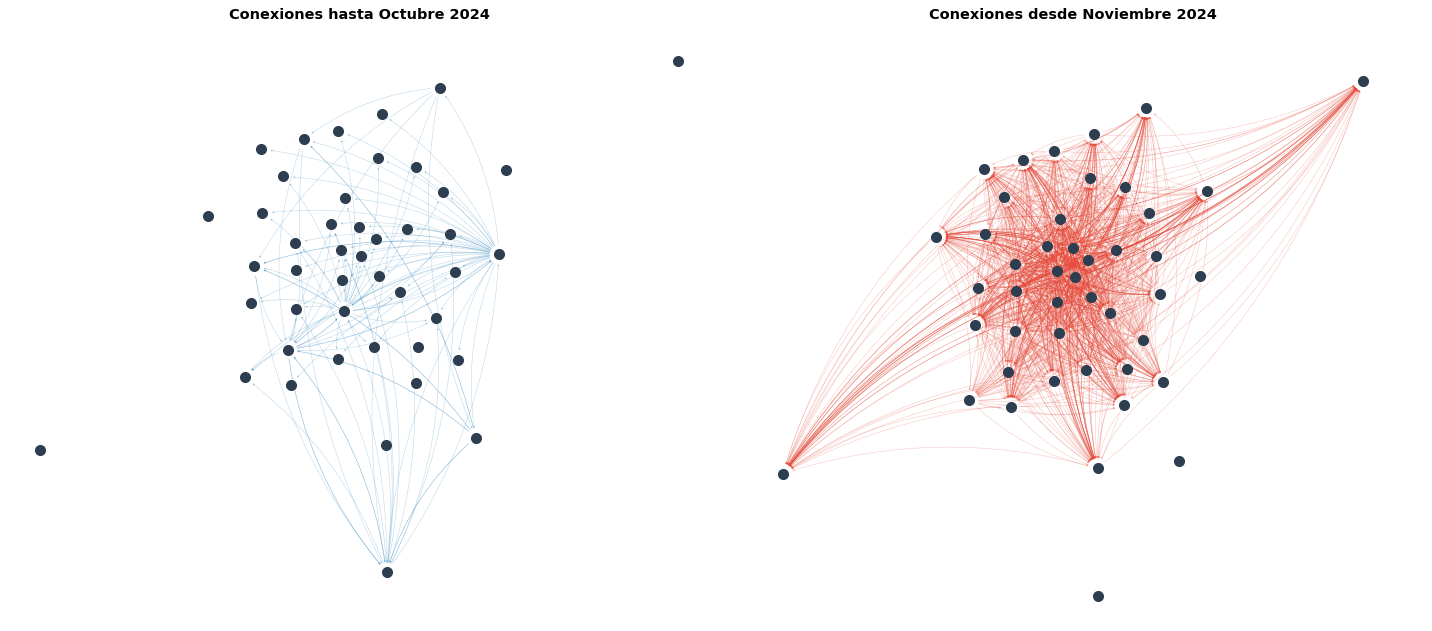

In [398]:
# 1. Crear el MULTIGRAFO DIRIGIDO
G_multi = nx.from_pandas_edgelist(
    df_downgrades,
    source="source",
    target="target",
    edge_attr=["weight", "periodo_mensual_A", "evento_crediticio"],
    create_using=nx.MultiDiGraph(),
)

# 2. CREAR DOS SUBGRAFOS INDEPENDIENTES
G_azul = nx.MultiDiGraph()
G_azul.add_nodes_from(G_multi.nodes(data=True))

G_rojo = nx.MultiDiGraph()
G_rojo.add_nodes_from(G_multi.nodes(data=True))

for u, v, k, data in G_multi.edges(keys=True, data=True):
    fecha = data.get("periodo_mensual_A")

    if int(str(fecha).replace("-", "")[:6]) <= 202410:
        G_azul.add_edge(u, v, key=k, **data)  # Época 1: Azul
    else:
        G_rojo.add_edge(u, v, key=k, **data)  # Época 2: Rojo

print(f"Nodos totales: {G_multi.number_of_nodes()}")
print(f"Enlaces Azules: {G_azul.number_of_edges()} | Enlaces Rojos: {G_rojo.number_of_edges()}")

# =====================================================================
# VISUALIZACIÓN EN PARALELO
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), dpi=80)
pos_multi = nx.spring_layout(G_multi, k=0.7, seed=42)

# --- 1. GRÁFICO IZQUIERDO: SOLO ENLACES AZULES ---
nx.draw_networkx_nodes(
    G_azul, pos_multi, node_size=80, node_color="#2c3e50", alpha=1, ax=ax1
)
nx.draw_networkx_edges(
    G_azul,
    pos_multi,
    edge_color="#2980b9",
    width=0.5,
    alpha=0.3,
    arrowsize=3,
    connectionstyle="arc3,rad=0.15",
    ax=ax1,
)
ax1.set_title("Conexiones hasta Octubre 2024", fontsize=13, fontweight="bold", pad=15)
ax1.axis("off")

# --- 2. GRÁFICO DERECHO: SOLO ENLACES ROJOS ---
nx.draw_networkx_nodes(
    G_rojo, pos_multi, node_size=80, node_color="#2c3e50", alpha=1, ax=ax2
)
nx.draw_networkx_edges(
    G_rojo,
    pos_multi,
    edge_color="#e74c3c",
    width=0.5,
    alpha=0.3,
    arrowsize=3,
    connectionstyle="arc3,rad=0.15",
    ax=ax2,
)
ax2.set_title("Conexiones desde Noviembre 2024", fontsize=13, fontweight="bold", pad=15)
ax2.axis("off")

plt.tight_layout()
plt.show()

Dimensiones de la matriz: (45, 45)


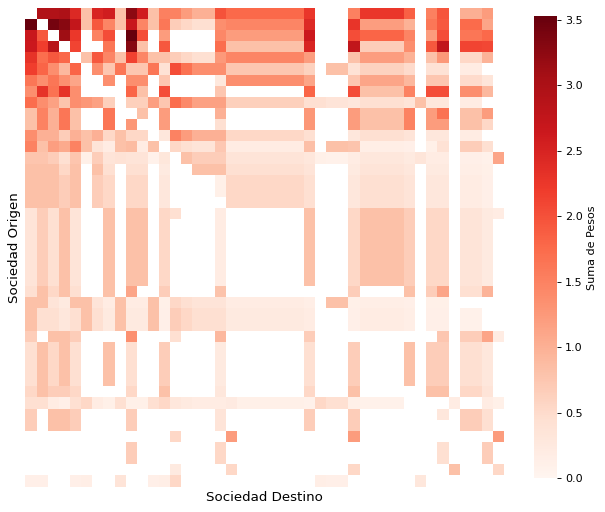

In [399]:
matriz_adyacencia = nx.to_pandas_adjacency(G_multi, weight="weight")
matriz_adyacencia = matriz_adyacencia.fillna(0.0)
print(f"Dimensiones de la matriz: {matriz_adyacencia.shape}")

orden_sources = df_downgrades.groupby("source")["weight"].sum()
nodos_ordenados = orden_sources.sort_values(ascending=False).index
matriz_ordenada = matriz_adyacencia.reindex(
    index=nodos_ordenados, columns=nodos_ordenados, fill_value=0.0
)

mascara_ceros = matriz_ordenada == 0.0

plt.figure(figsize=(8, 8), dpi=80)

# Graficar el Heatmap
sns.heatmap(
    matriz_ordenada,
    mask=mascara_ceros,
    cmap="Reds",
    # vmax=1.0,
    vmin=0.0,
    square=True,
    cbar_kws={
        "label": "Suma de Pesos",
        "shrink": 0.75,
    },
    xticklabels=False,
    yticklabels=False,
)
# # 5. Detalles estéticos
# plt.title(
#     "Matriz de Adyacencia Pesada",
#     fontsize=12,
#     fontweight="bold",
#     pad=15,
# )
plt.xlabel("Sociedad Destino", fontsize=12)
plt.ylabel("Sociedad Origen", fontsize=12)

plt.tight_layout()
plt.savefig("matriz.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()

In [400]:
es_fuertemente_conexa = nx.is_strongly_connected(G_multi)
print(f"¿La red de Downgrades es fuertemente conexa?: {es_fuertemente_conexa}")

¿La red de Downgrades es fuertemente conexa?: False


Nodos en toda la red: 45
Enlaces en toda la red (Eventos totales): 1795
Grado de Salida Medio: 39.89
Grado de Entrada Medio: 39.89
Clustering promedio Dirigido (Fagiolo, 2007): 0.6456
Densidad Ponderada Dirigida (rho): 0.416824


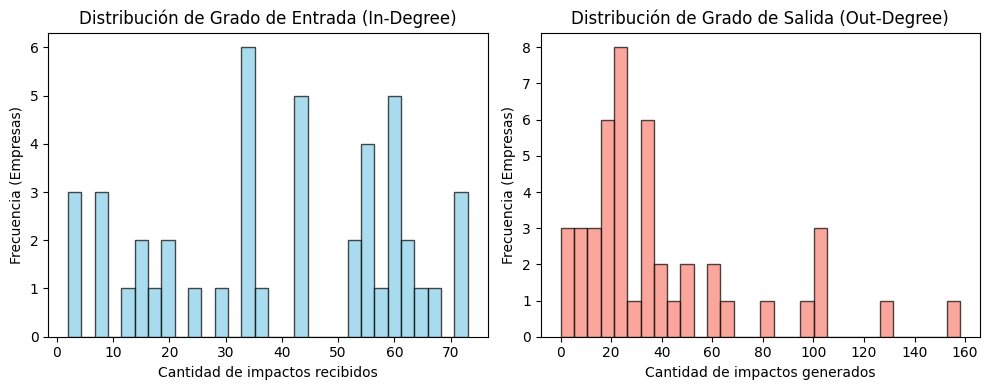

In [401]:
# ---------------------------------------------------------------------
# 2. Descripción del dataset (Métricas estructurales sobre Multigrafo)
# ---------------------------------------------------------------------
print(f"Nodos en toda la red: {G_multi.number_of_nodes()}")
print(f"Enlaces en toda la red (Eventos totales): {G_multi.number_of_edges()}")

# 1. Grado de Salida Medio (Out-Degree): Cuántos impactos genera una empresa en promedio
out_grados = dict(G_multi.out_degree()).values()
out_grado_medio = sum(out_grados) / len(out_grados)

# 2. Grado de Entrada Medio (In-Degree): Cuántos impactos recibe una empresa en promedio
in_grados = dict(G_multi.in_degree()).values()
in_grado_medio = sum(in_grados) / len(in_grados)

print(f"Grado de Salida Medio: {out_grado_medio:.2f}")
print(f"Grado de Entrada Medio: {in_grado_medio:.2f}")

# =====================================================================
# Clustering Promedio DIRIGIDO (Fagiolo, 2007)
# =====================================================================

# Se pasa de un multigrafo a un grafo simple (pero sigue siendo dirigido y pesado)
# G_simple = nx.DiGraph(G_multi)

G_simple = nx.DiGraph()

for u, v, data in G_multi.edges(data=True):
    weight = data.get('weight', 1.0)
    if G_simple.has_edge(u, v):
        G_simple[u][v]['weight'] += weight
    else:
        G_simple.add_edge(u, v, weight=weight)

clustering_prom_dir = nx.average_clustering(G_simple)
print(f"Clustering promedio Dirigido (Fagiolo, 2007): {clustering_prom_dir:.4f}")

# Densidad
N = G_simple.number_of_nodes()

if N > 1:
    # Sumamos el atributo 'weight' de todas las aristas presentes
    suma_pesos = G_simple.size(weight='weight')

    # Aplicamos la fórmula: Suma(W_ab) / (N * (N - 1))
    densidad_ponderada = suma_pesos / (N * (N - 1))
else:
    densidad_ponderada = 0.0
print(f"Densidad Ponderada Dirigida (rho): {densidad_ponderada:.6f}")

# ---------------------------------------------------------------------
# Visualización de las Distribuciones de Grado
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.hist(in_grados, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de Grado de Entrada (In-Degree)')
plt.xlabel('Cantidad de impactos recibidos')
plt.ylabel('Frecuencia (Empresas)')

plt.subplot(122)
plt.hist(out_grados, bins=30, color='salmon', edgecolor='black', alpha=0.7)
plt.title('Distribución de Grado de Salida (Out-Degree)')
plt.xlabel('Cantidad de impactos generados')
plt.ylabel('Frecuencia (Empresas)')

plt.tight_layout()
plt.show()

In [402]:
# Encontrar el nodo con el out-degree máximo
nodo_max, grado_max = max(G_multi.out_degree(), key=lambda x: x[1])

print(f"La empresa con más impactos generados es: {nodo_max} (Grado: {grado_max})")

La empresa con más impactos generados es: 33711944899 (Grado: 158)


In [403]:
# Contar conexiones repetidas vs vecinos únicos
vecinos_unicos = list(G_multi.successors(nodo_max))
print(f"Afectó a {len(vecinos_unicos)} empresas únicas.")
print(f"Promedio de impactos por empresa afectada: {grado_max / len(vecinos_unicos):.1f} veces.")

Afectó a 38 empresas únicas.
Promedio de impactos por empresa afectada: 4.2 veces.


In [404]:
# =====================================================================
# FUNCIÓN DE COMPARACIÓN ADAPTADA A REDES DIRIGIDAS
# =====================================================================
def compare_properties(graphs, labels):
    results = []
    for g, l in zip(graphs, labels):
        # Coeficiente de clustering dirigido nativo (Fagiolo, 2007)
        c_clustering = nx.average_clustering(g)

        # Distancia media adaptada a las restricciones de red dirigida
        try:
            if nx.is_strongly_connected(g):
                # Si es fuertemente conexo, calcula la distancia global real
                avg_path = nx.average_shortest_path_length(g)
            else:
                # Si no lo es (como los modelos teóricos), mide el núcleo central (SCC)
                componentes = max(nx.strongly_connected_components(g), key=len)
                subgrafo_nucleo = g.subgraph(componentes)

                if subgrafo_nucleo.number_of_nodes() > 1:
                    avg_path = nx.average_shortest_path_length(subgrafo_nucleo)
                else:
                    avg_path = np.nan
        except (nx.NetworkXError, nx.NetworkXNoPath):
            avg_path = np.nan

        results.append(
            {
                "Modelo": l,
                "C. clustering": c_clustering,
                "Distancia media": avg_path,
            }
        )
    return pd.DataFrame(results)

n = G_simple.number_of_nodes()
m = G_simple.number_of_edges()

k_avg_dirigido = m / n

# =====================================================================
# 2. GENERACIÓN DE PROTOTIPOS TEÓRICOS DIRIGIDOS
# (NO SE USAN PESOS EN ESTOS MODELOS)
# =====================================================================
# Erdős-Rényi (Modelo Nulo Estructural)
ER = nx.gnm_random_graph(n, m, directed=True, seed=42)

# Watts-Strogatz (Mundo Pequeño Dirigido)
k_ws = int(k_avg_dirigido) if int(k_avg_dirigido) % 2 == 0 else int(k_avg_dirigido) + 1
k_ws = max(2, k_ws)
WS = nx.watts_strogatz_graph(n, k_ws, 0.1, seed=42).to_directed()

# Barabási-Albert (Escala Libre Dirigida)
BA_grafo= nx.scale_free_graph(n, alpha=0.41, beta=0.54, gamma=0.05, seed=42)
BA = nx.DiGraph(BA_grafo)
if BA.number_of_nodes() > n:
    BA = BA.subgraph(list(G_simple.nodes()))

# =====================================================================
# 3. EJECUCIÓN DE LA COMPARACIÓN METODOLÓGICA
# =====================================================================
models = [G_simple, ER, WS, BA]
labels = [
    "Grafo Simple",
    "Erdős-Rényi",
    "Watts-Strogatz",
    "Barabási-Albert"
]

comparison_df = compare_properties(models, labels)

In [405]:
comparison_df

,Modelo,C. clustering,Distancia media
0,Grafo Simple,0.645576,1.470653
1,Erdős-Rényi,0.554903,1.445960
2,Watts-Strogatz,0.623431,1.454545
3,Barabási-Albert,0.040890,1.333333


ANÁLISIS DE COMUNIDADES
Modularidad Louvain: 0.095
Número de comunidades: 4


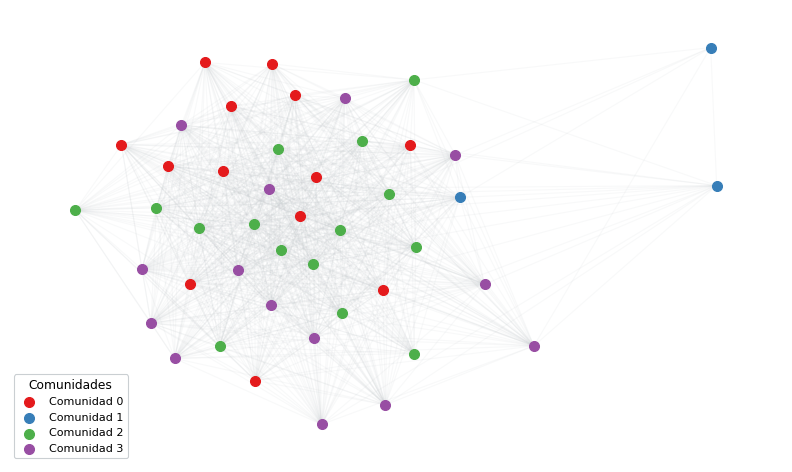

In [406]:
# Transformacion a no dirigido para Louvain
G_undir = G_simple.to_undirected()

# =====================================================================
# EJECUCIÓN DE LOUVAIN PONDERADO
# =====================================================================
partition = community_louvain.best_partition(G_undir, weight="weight", random_state=42)
modularity = community_louvain.modularity(partition, G_undir, weight="weight")

print("=" * 60)
print("ANÁLISIS DE COMUNIDADES")
print("=" * 60)
print(f"Modularidad Louvain: {modularity:.3f}")
print(f"Número de comunidades: {len(set(partition.values()))}")

# =====================================================================
# VISUALIZACIÓN DE LAS COMUNIDADES
# =====================================================================
plt.figure(figsize=(10, 6), dpi=80)

# Calculamos el layout de resortes
pos_comunidades = nx.spring_layout(G_undir, k=0.5, seed=42)

nx.draw_networkx_edges(
    G_undir,
    pos_comunidades,
    alpha=0.1,
    edge_color="#bdc3c7"
)

lista_comunidades = sorted(list(set(partition.values())))
mapa_colores = plt.cm.Set1

for i, com_id in enumerate(lista_comunidades):
    nodos_comunidad = [nodo for nodo, com in partition.items() if com == com_id]

    nx.draw_networkx_nodes(
        G_undir,
        pos_comunidades,
        nodelist=nodos_comunidad,
        node_size=80,
        node_color=[mapa_colores(i)],
        alpha=1,
        label=f"Comunidad {com_id}"
    )

plt.legend(
    title="Comunidades",
    title_fontsize=11,
    fontsize=10,
    loc="lower left",
    frameon=True,
    shadow=False,
    facecolor="white",
    edgecolor="#bdc3c7"
)
#
# plt.title(
#     "Detección de Comunidades Sectoriales de Riesgo Crítico (Algoritmo de Louvain)",
#     fontsize=13,
#     fontweight="bold",
#     pad=20,
# )
plt.savefig("communities.png", bbox_inches="tight", dpi=300)
plt.axis("off")
plt.tight_layout()

plt.show()

In [407]:
import networkx as nx
from infomap import Infomap

# 2. Calcular el umbral (ej: dejar solo el 25% de las aristas más fuertes)
pesos = [data['weight'] for u, v, data in G_simple.edges(data=True)]
umbral_corte = np.percentile(pesos, 75)  # Ajustá este percentil (75, 80, 90...)
print(f"Umbral de corte seleccionado: {umbral_corte}")

# 3. Crear el verdadero G_dirigido filtrado
G_aux = nx.DiGraph()
for u, v, data in G_simple.edges(data=True):
    if data['weight'] >= umbral_corte:
        G_aux.add_edge(u, v, weight=data['weight'])

print(f"Nodos post-filtro: {G_aux.number_of_nodes()}")
print(f"Aristas post-filtro: {G_aux.number_of_edges()}")

# 2. Inicializar Infomap para un grafo dirigido estándar
# Ya no necesitamos el parámetro --multilayer
im = Infomap("--directed --teleportation-probability 0.05")

# 3. Mapear los nodos a IDs enteros
node_to_idx = {node: idx for idx, node in enumerate(G_aux.nodes())}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

# 4. Pasar los enlaces colapsados a Infomap
for u, v, data in G_aux.edges(data=True):
    u_idx = node_to_idx[u]
    v_idx = node_to_idx[v]
    weight = data['weight']

    # Usamos add_link para grafos de una sola capa (origen, destino, peso)
    im.add_link(u_idx, v_idx, weight)

# 5. Ejecutar el algoritmo
print("Ejecutando Infomap sobre el grafo colapsado...")
im.run()

# 6. Extraer las comunidades
comunidades = {}
for node in im.tree:
    if node.is_leaf:
        node_idx = node.node_id
        original_node = idx_to_node[node_idx]
        comunidades[original_node] = node.module_id

print(f"¡Listo! Se encontraron {im.num_top_modules} comunidades.")

Umbral de corte seleccionado: 0.8187307530779818
Nodos post-filtro: 45
Aristas post-filtro: 427
Ejecutando Infomap sobre el grafo colapsado...
¡Listo! Se encontraron 2 comunidades.
  Infomap v2.12.0 starts at 2026-06-15 17:19:00
  -> Input network: 
  -> No file output!
  -> Configuration: directed
                    teleportation-probability = 0.05
  OpenMP 202011 detected with 12 threads...
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'directed'... 
  -> Using unrecorded teleportation to links. 
  -> PageRank calculation done in 50 iterations with error 1.23165367e-16.

  => Sum node flow: 1, sum link flow: 1
Build internal network with 45 nodes and 427 links...
  -> One-level codelength: 4.95990059
  -> Runtime: 12 CPUs available, thread budget 12 (hardware_concurrency), inner parallelization disabled.

Trial 1/1 starting at 2026-06-15 17:19:00
Two-level compression: 0.93% 0.031% 
Partitioned to c

/var/folders/8q/7djkg4_55rsgfbzr3shf6lsc0000gn/T/ipykernel_68108/4149564678.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", num_comunidades)


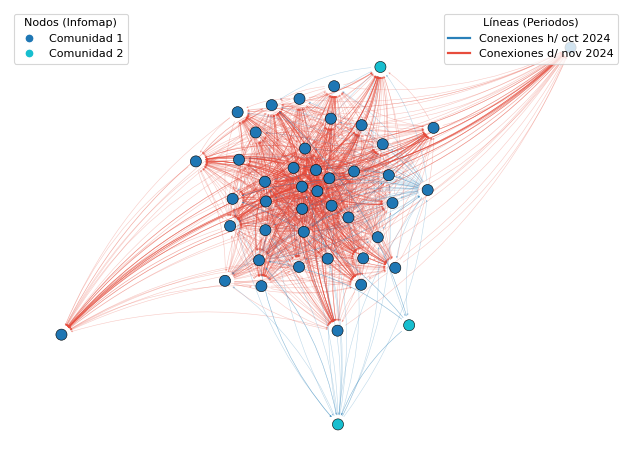

In [408]:
# =====================================================================
# REUTILIZACIÓN Y PREPARACIÓN DE COLORES DE NODOS
# =====================================================================
# Extraemos las comunidades únicas a partir del diccionario que calculaste con Infomap
comunidades_unicas = list(set(comunidades.values()))
num_comunidades = len(comunidades_unicas)

# Creamos una paleta de colores para las comunidades (tab10 o tab20 según cuántas tengas)
cmap = plt.cm.get_cmap("tab10", num_comunidades)
color_comunidad_map = {com: cmap(i) for i, com in enumerate(comunidades_unicas)}

# Mapeamos los colores respetando el orden exacto de los nodos en G_multi
node_colors = []
for node in G_multi.nodes():
    id_comunidad = comunidades.get(node, -1)
    if id_comunidad != -1:
        node_colors.append(color_comunidad_map[id_comunidad])
    else:
        node_colors.append("#7f8c8d")  # Gris por si algún nodo quedó huérfano

# =====================================================================
# NUEVA VISUALIZACIÓN (REUTILIZANDO POS_MULTI Y EDGE_COLORS)
# =====================================================================
plt.figure(figsize=(8, 6), dpi=80)

# Dibujamos los nodos usando las posiciones ORIGINALES (pos_multi) y los nuevos colores
nx.draw_networkx_nodes(
    G_multi,
    pos_multi,          # <--- Reutilizado
    node_size=100,      # Un toque más grande para que se aprecie el color de la comunidad
    node_color=node_colors,
    alpha=1,
    edgecolors='black', # Borde sutil para separar nodos encimados
    linewidths=0.5
)

# Dibujamos las aristas exactamente con tus parámetros y colores originales
nx.draw_networkx_edges(
    G_multi,
    pos_multi,          # <--- Reutilizado
    edge_color=edge_colors, # <--- Reutilizado
    width=0.5,
    alpha=0.3,
    arrowsize=3,
    connectionstyle="arc3,rad=0.15",
)

# =====================================================================
# LEYENDAS COMBINADAS (Periodos de Aristas + Comunidades de Nodos)
# =====================================================================
# 1. Leyenda de aristas (Tu lógica original)
proxies_aristas = [
    plt.Line2D([0], [0], color="#2980b9", lw=2),
    plt.Line2D([0], [0], color="#e74c3c", lw=2),
]
leyenda_aristas = plt.legend(
    proxies_aristas,
    ["Conexiones h/ oct 2024", "Conexiones d/ nov 2024"],
    loc="upper right",
    frameon=True,
    fontsize=10,
    title="Líneas (Periodos)"
)
plt.gca().add_artist(leyenda_aristas) # Fijamos la primera leyenda para que no se sobreescriba

# 2. Leyenda de comunidades (Nodos)
proxies_nodos = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_comunidad_map[com], markersize=8)
    for com in comunidades_unicas
]
plt.legend(
    proxies_nodos,
    [f"Comunidad {com}" for com in comunidades_unicas],
    loc="upper left",
    frameon=True,
    fontsize=10,
    title="Nodos (Infomap)"
)

plt.axis("off")
plt.tight_layout()
plt.savefig("network_comunidades_y_épocas.png", bbox_inches="tight", dpi=300)
plt.show()

In [409]:
df_comu= pd.DataFrame(list(comunidades.items()), columns=['cuit', 'comunidad'])
df_comu['cuit'] = df_comu['cuit'].astype(str)
df_comu['cuit']=df_comu['cuit'].astype("int64")


In [410]:
# df_g = df_downgrades.groupby(['source', 'target'], as_index=False)['weight'].sum()

In [411]:
df_comu['comunidad'].value_counts()

comunidad
1    42
2     3
Name: count, dtype: int64

In [412]:
df_comu[df_comu['comunidad'] == 1]

,cuit,comunidad
0,30714814229,1
1,30682434720,1
2,30501062150,1
3,30712156909,1
4,30593174057,1
5,30658531332,1
6,30511190238,1
7,30689001269,1
8,33711944899,1
9,30502112259,1


In [413]:
df_comu[df_comu['comunidad'] == 2]


,cuit,comunidad
42,30629827060,2
43,33715827129,2
44,30638375628,2


In [ ]:
df_c2[df_c2['weight'] >= umbral_corte]

In [ ]:
df_c2_total = pd.merge(df_downgrades, df_c2[df_c2['weight'] >= umbral_corte], how='inner', on=['source', 'target'])

In [ ]:
df_c2_total.sort_values(by=['source', 'target'])

In [ ]:
actividades = pd.read_csv("/Users/sofiascaiano/Documents/maestria/TT1/project/actividad_afip/data/output/actividades_economicas.csv")
actividades = actividades[actividades['es_actividad_principal'] == 1]
actividades['id_actividad'] = actividades['id_actividad'].astype(str).str.zfill(6)
actividades['grupo'] = actividades['id_actividad'].str[:2]
actividades['subgrupo'] = actividades['id_actividad'].str[:3]
clae = pd.read_csv("/Users/sofiascaiano/Documents/maestria/TT1/project/actividad_afip/data/output/clae_afip.csv")
clae['grupo'] = clae['grupo'].astype('Int64').astype(str).str.zfill(2)
clae['subgrupo'] = clae['subgrupo'].astype('Int64').astype(str).str.zfill(3)

In [ ]:
actividades_2 = pd.merge(actividades, clae[clae['subgrupo'].isna()][['grupo', 'seccion', 'descripcion']], on='grupo', how='left', suffixes=('', '_grupo'))
actividades_3 = pd.merge(actividades_2, clae[~clae['subgrupo'].isna()][['subgrupo', 'descripcion']], on='subgrupo', how='left', suffixes=('', '_subgrupo'))
actividades_4 = pd.merge(actividades_3, clae[clae['grupo'].isna()][['seccion', 'descripcion']], on='seccion', how='left', suffixes=('', '_seccion'))
actividades_final = actividades_4[['cuit_consultado', 'id_actividad', 'descripcion', 'seccion', 'descripcion_grupo', 'descripcion_subgrupo', 'descripcion_seccion']]
actividades_final.columns = ['cuit', 'id_actividad', 'descripcion_actividad', 'seccion', 'descripcion_grupo', 'descripcion_subgrupo', 'descripcion_seccion']

In [ ]:
actividades_final.descripcion_seccion.value_counts(dropna=False)

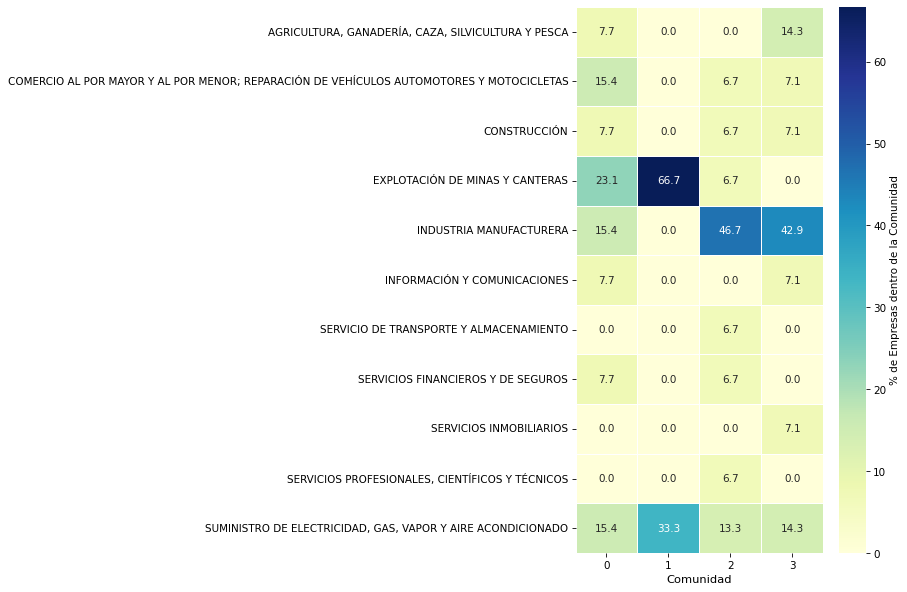

In [415]:
# =====================================================================
# MAPEO DE COMUNIDADES
# =====================================================================
df_louvain = pd.DataFrame(list(partition.items()), columns=['cuit', 'comunidad'])
df_louvain['cuit'] = df_louvain['cuit'].astype(str)
actividades_final['cuit'] = actividades_final['cuit'].astype(str)
df_analisis = df_louvain.merge(actividades_final, on='cuit', how='left')
df_analisis['descripcion_seccion'] = df_analisis['descripcion_seccion'].fillna('Sin Especificar')

# =====================================================================
# MATRIZ DE CONTINGENCIA (Frecuencias absolutas y relativas)
# =====================================================================
# Contamos cuántas empresas de cada sector cayeron en cada comunidad
matriz_contingencia = pd.crosstab(
    df_analisis['descripcion_seccion'],
    df_analisis['comunidad'],
    margins=True,
    margins_name="Total General"
)

# Calculamos los porcentajes por columna
matriz_porcentajes = pd.crosstab(
    df_analisis['descripcion_seccion'],
    df_analisis['comunidad'],
    normalize='columns'
) * 100

# =====================================================================
# VISUALIZACIÓN HEATMAP
# =====================================================================
plt.figure(figsize=(12, 8), dpi=75)
sns.heatmap(
    matriz_porcentajes,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': '% de Empresas dentro de la Comunidad'}
)

# plt.title("Perfil Sectorial de las Comunidades de Riesgo (Louvain)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Comunidad", fontsize=11)
plt.ylabel("", fontsize=11)
plt.tight_layout()

# Guardamos el PDF de alta calidad
plt.savefig("composicion_sectorial.png", bbox_inches="tight", dpi=300)
plt.show()

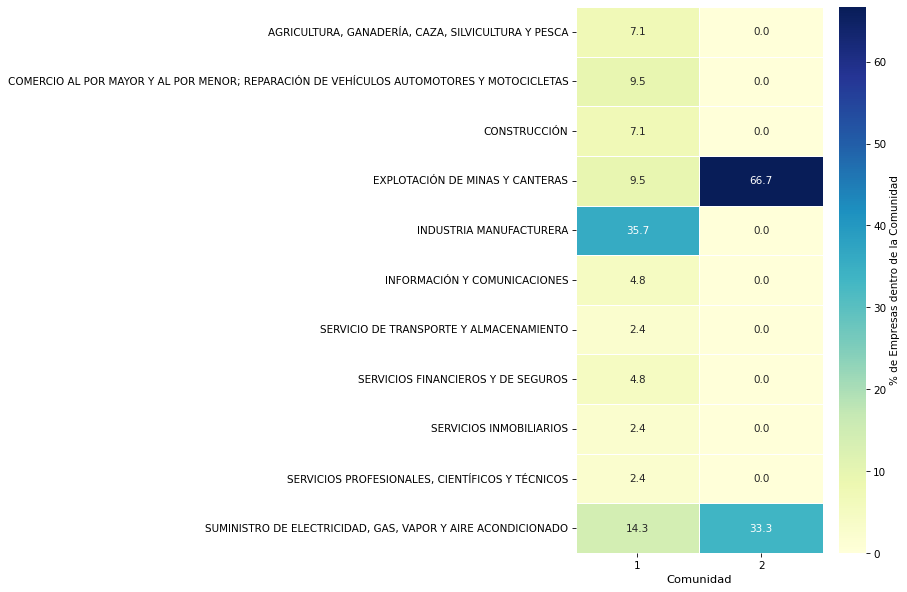

In [416]:
# =====================================================================
# MAPEO DE COMUNIDADES
# =====================================================================
df_infomap= pd.DataFrame(list(comunidades.items()), columns=['cuit', 'comunidad'])
df_infomap['cuit'] = df_infomap['cuit'].astype(str)
actividades_final['cuit'] = actividades_final['cuit'].astype(str)
df_analisis = df_infomap.merge(actividades_final, on='cuit', how='left')
df_analisis['descripcion_seccion'] = df_analisis['descripcion_seccion'].fillna('Sin Especificar')

# =====================================================================
# MATRIZ DE CONTINGENCIA (Frecuencias absolutas y relativas)
# =====================================================================
# Contamos cuántas empresas de cada sector cayeron en cada comunidad
matriz_contingencia = pd.crosstab(
    df_analisis['descripcion_seccion'],
    df_analisis['comunidad'],
    margins=True,
    margins_name="Total General"
)

# Calculamos los porcentajes por columna
matriz_porcentajes = pd.crosstab(
    df_analisis['descripcion_seccion'],
    df_analisis['comunidad'],
    normalize='columns'
) * 100

# =====================================================================
# VISUALIZACIÓN HEATMAP
# =====================================================================
plt.figure(figsize=(12, 8), dpi=75)
sns.heatmap(
    matriz_porcentajes,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': '% de Empresas dentro de la Comunidad'}
)

# plt.title("Perfil Sectorial de las Comunidades de Riesgo (Louvain)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Comunidad", fontsize=11)
plt.ylabel("", fontsize=11)
plt.tight_layout()

# Guardamos el PDF de alta calidad
plt.savefig("composicion_sectorial.png", bbox_inches="tight", dpi=300)
plt.show()

In [422]:
def calcular_debtrank_y_activacion(G_multi, umbral):
    """
    Calcula el DebtRank clásico (Severidad) y un indicador paralelo
    de Proporción de Sociedades Activadas (Incidencia/Downgrades reales).
    """
    nodos = list(G_multi.nodes())
    N = len(nodos)
    node_to_idx = {nodo: idx for idx, nodo in enumerate(nodos)}

    # 1. Matriz de Adyacencia Ponderada Absoluta
    A = np.zeros((N, N))
    for u, v, data in G_multi.edges(data=True):
        idx_u = node_to_idx[u]
        idx_v = node_to_idx[v]
        A[idx_u][idx_v] += data.get('weight', 1.0)

    # 2. Matriz de Impacto Normalizada
    in_strength_absoluto = A.sum(axis=0)
    P = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            if A[i][j] > 0 and in_strength_absoluto[j] > 0:
                P[i][j] = A[i][j] / in_strength_absoluto[j]

    resultados_dr = {}
    resultados_activacion = {}  # Nuevo diccionario para el indicador paralelo

    # 3. Simulación Dinámica
    UMBRAL_DOWNGRADE = umbral

    for nodo_shock in nodos:
        idx_shock = node_to_idx[nodo_shock]

        h = np.zeros(N)
        h[idx_shock] = 1.0

        estado = np.zeros(N)  # 0: Sana/Acumulando, 1: ACTIVA, 2: Inactiva
        estado[idx_shock] = 1

        paso = 0
        while np.any(estado == 1) and paso < N:
            activos = estado == 1
            impactos_totales = np.dot(h * activos, P)
            nuevos_downgrades = np.zeros(N, dtype=bool)

            for j in range(N):
                if estado[j] == 0 and impactos_totales[j] > 0:
                    h[j] = min(1.0, h[j] + impactos_totales[j])
                    if h[j] >= UMBRAL_DOWNGRADE:
                        nuevos_downgrades[j] = True

            estado[activos] = 2
            estado[nuevos_downgrades] = 1
            paso += 1

        # -----------------------------------------------------------------
        # METRICA 1: DebtRank Clásico (Severidad del estrés en el mercado)
        # -----------------------------------------------------------------
        score_debtrank = sum(h) - 1.0
        resultados_dr[nodo_shock] = (score_debtrank / (N - 1)) * 100

        # -----------------------------------------------------------------
        # METRICA 2: Proporción de Sociedades Activadas (Incidencia de Downgrades)
        # -----------------------------------------------------------------
        # Contamos cuántos nodos terminaron en estado 1 o 2 (excluyendo la semilla)
        # Es decir, todos los que sufrieron un downgrade provocado por la simulación.
        sociedades_contagiadas = sum(1 for j in range(N) if j != idx_shock and estado[j] > 0)

        # Lo expresamos como porcentaje del resto de la red
        resultados_activacion[nodo_shock] = (sociedades_contagiadas / (N - 1)) * 100

    return resultados_dr, resultados_activacion

# =====================================================================
# EJECUCIÓN
# =====================================================================
# 1. Calculamos ambos diccionarios con la nueva función
scores_dr, scores_act = calcular_debtrank_y_activacion(G_multi, umbral=0.5)

# 2. Creamos los DataFrames individuales
df_dr = pd.DataFrame(list(scores_dr.items()), columns=['cuit', 'DebtRank_Severidad_%'])
df_act = pd.DataFrame(list(scores_act.items()), columns=['cuit', 'Porcentaje_Downgrades_Provocados'])

# 3. Aseguramos que el CUIT sea string en todos los DataFrames antes del merge
df_dr['cuit'] = df_dr['cuit'].astype(str)
df_act['cuit'] = df_act['cuit'].astype(str)
actividades_final['cuit'] = actividades_final['cuit'].astype(str)  # <-- ESTA LÍNEA CORRIGE EL ERROR

# 4. Consolidamos los datos mediante los merges sucesivos
df_debtrank_final = (
    df_dr
    .merge(df_act, on='cuit', how='inner')
    .merge(actividades_final, on='cuit', how='left')
    .sort_values(by='Porcentaje_Downgrades_Provocados', ascending=False)
)

print("\n" + "="*85)
print("RANKING DE IMPACTO SISTÉMICO Y CASIDAS DE CONTAGIO (SOBRE ENLACES TEMPORALES)")
print("="*85)
print(df_debtrank_final[['cuit', 'DebtRank_Severidad_%', 'Porcentaje_Downgrades_Provocados', 'descripcion_seccion']].head(10).to_string(index=False))
print("="*85)



RANKING DE IMPACTO SISTÉMICO Y CASIDAS DE CONTAGIO (SOBRE ENLACES TEMPORALES)
       cuit  DebtRank_Severidad_%  Porcentaje_Downgrades_Provocados                                         descripcion_seccion
30592724541              9.660643                          4.545455                                     INDUSTRIA MANUFACTURERA
30629827060              3.305915                          2.272727 SUMINISTRO DE ELECTRICIDAD, GAS, VAPOR Y AIRE ACONDICIONADO
30500179151              1.221443                          0.000000                                INFORMACIÓN Y COMUNICACIONES
30690076043              3.462130                          0.000000                                INFORMACIÓN Y COMUNICACIONES
30500658912              1.882074                          0.000000                                     INDUSTRIA MANUFACTURERA
30506733932              1.221443                          0.000000                             EXPLOTACIÓN DE MINAS Y CANTERAS
30547174913              

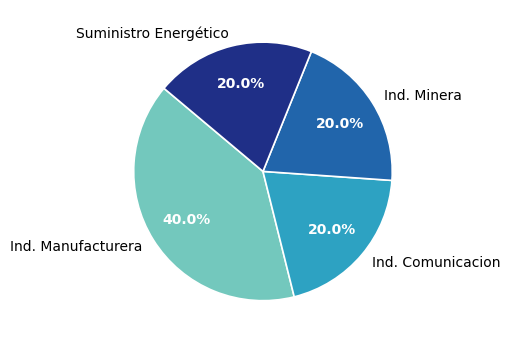

In [420]:
# 1. Filtrar las 8 sociedades principales
df_top = df_debtrank_final.head(5).copy()

# 2. Definir un diccionario de mapeo para acortar los nombres largos
# Agregá acá las variantes si tenés otros sectores en el top 8
alias_sectores = {
    'SUMINISTRO DE ELECTRICIDAD, GAS, VAPOR Y AIRE ACONDICIONADO': 'Suministro Energético',
    'INDUSTRIA MANUFACTURERA': 'Ind. Manufacturera',
    'EXPLOTACIÓN DE MINAS Y CANTERAS': 'Ind. Minera',
    'AGRICULTURA, GANADERÍA, CAZA, SILVICULTURA Y PESCA': 'Ind. Agricola',
    'INFORMACIÓN Y COMUNICACIONES': 'Ind. Comunicacion'
}

# Aplicamos el mapeo. Si un sector no está en el diccionario, conserva su nombre original
df_top['sector_corto'] = df_top['descripcion_seccion'].map(alias_sectores).fillna(df_top['descripcion_seccion'])

# 3. Agrupar por el nuevo nombre corto
df_sectores = df_top.groupby('sector_corto').size().reset_index(name='cantidad')
df_sectores['porcentaje'] = (df_sectores['cantidad'] / 8) * 100
df_sectores = df_sectores.sort_values(by='porcentaje', ascending=False)

# # 4. Colores y configuración del gráfico
# colores = ['#1f77b4', '#aec7e8', '#7f7f7f']

num_sectores = len(df_sectores)
colores = plt.cm.YlGnBu(np.linspace(0.4, 0.9, num_sectores))

plt.figure(figsize=(5, 5)) # Un tamaño de 5x5 es ideal para el espacio de la columna en Beamer
wedges, texts, autotexts = plt.pie(
    df_sectores['porcentaje'],
    labels=df_sectores['sector_corto'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colores,
    textprops=dict(color="black", size=10), # Texto exterior más legible
    pctdistance=0.7,
    wedgeprops=dict(edgecolor='w', linewidth=1.2)
)

# Estilizar los porcentajes de adentro
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_size(10)

plt.tight_layout()

# Guardar la imagen con fondo transparente
plt.savefig('pie_chart_sectores.png', dpi=300, transparent=True)
plt.show()
plt.close()